# Classical radiation

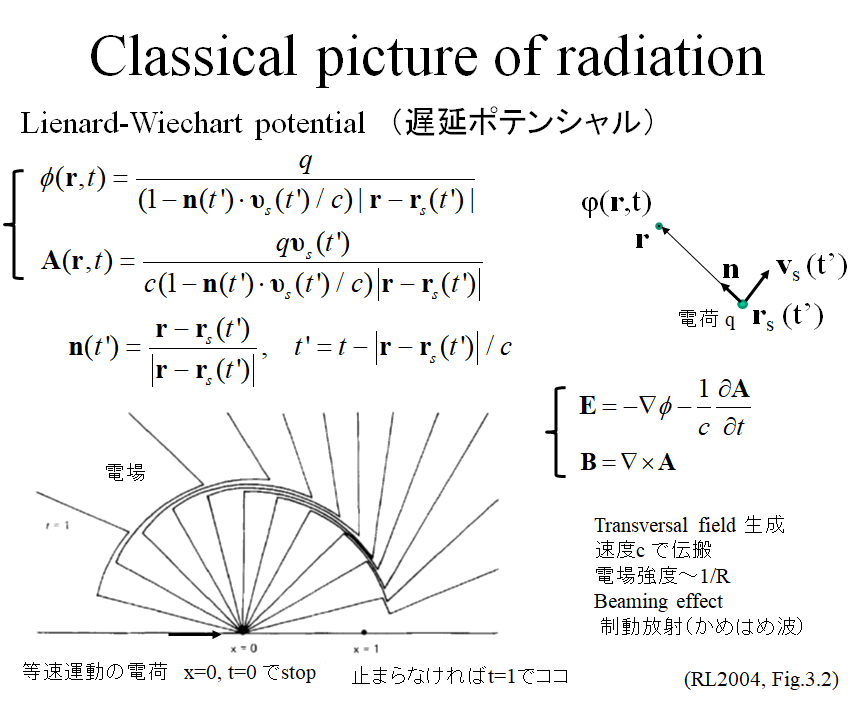  


目標：放射の可視化、適用：  
・双極子放射  
・サイクロトロン放射、ジャイロシンクロトロン放射  
・制動放射（X線）、「粒子加速放射」

In [1]:
import sys
sys.path.append("D:/home/Python/")
import matplotlib.pyplot as plt   # module for plotting
plt.style.use("ggplot")
import numpy as np                # module for vectorized numeric calculation

### Linear stop

$
\quad F/m = \frac{dv}{dt}=\frac{d^2x}{dt^2} \\
\quad t<0 : \qquad \quad v=v, \quad x=vt \\
\quad 0\le t<\Delta t : \quad v=v(1-\frac{t}{\Delta t}), \quad x=vt-\frac{t^2}{2\Delta t} \\
\quad \Delta t \le t : \qquad \quad v=0, \quad x=\frac{v\Delta t}{2} \
$

n_ii2= 10


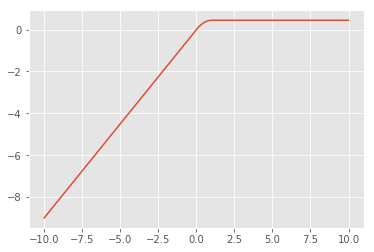

In [2]:
def vrp(t):
    
    # linear stop
    v=0.9
    dt=1e-0
    vx = np.zeros(t.size)     ; x = np.zeros(t.size)
    vy = np.zeros(t.size)     ; y = np.zeros(t.size)
    vz = np.zeros(t.size)     ; z = np.zeros(t.size)
    ii1 = np.where(t<0)[0]          
    ii2 = np.where((t>=0) & (t<dt))[0] 
    ii3 = np.where(t>=dt)               
    vx[ii1] = v                ; x[ii1] = v*(t[ii1]-0)
    vx[ii2] = v*(1-t[ii2]/dt)  ; x[ii2] = v*t[ii2]*(1-t[ii2]/2/dt)
    vx[ii2] = 0                ; x[ii3] = v*dt/2
    vp = np.array([vx,vy,vz]) ;   rp = np.array([x,y,z])
    print("n_ii2=",ii2.size)
    return vp,rp

#------------------------------------
nt = 201
tp = np.linspace(-10,10,nt)
vp,rp = vrp(tp)
plt.plot(tp,rp[0,:])
plt.show()


In [5]:
# phi in particle time
w2 = 50 ;  nw = w2*2+1
x = np.linspace(-w2,w2,nw)
y = np.linspace(-w2,w2,nw)
z = np.linspace(-w2,w2,nw)
phi = np.zeros([nw,nw,nt])
td = np.zeros([nw,nw,nt])
c = 1.
q = 1.

for i in range(0,nw):
    for j in range(0,nw):
        dr = np.array([x[i] - rp[0,:], y[j]-rp[1,:] ])
        dd = np.sqrt(dr[0,:]**2 + dr[1,:]**2)
        n = dr/dd.clip(min=1)
        td1 = tp + dd/c
        td[i,j,:] = td1
        den = (dd.clip(min=1)*(1 - (n[0,:]*vp[0,:] + n[1,:]*vp[1,:]) /c))
        phi[i,j,:] = q/den


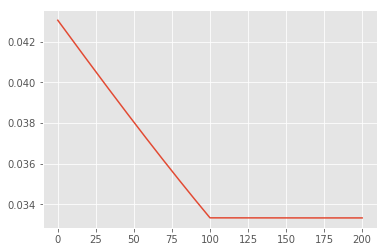

In [6]:
plt.plot(phi[50,20,:])
plt.show()

In [7]:
# phi in observers time
phi2 = phi
for i in range(0,nw):
    for j in range(0,nw):
        

SyntaxError: unexpected EOF while parsing (<ipython-input-7-b63f3c777703>, line 5)

In [8]:
a='Fe_I'
a.find('_')
a[0:a.find('_')]

'Fe'

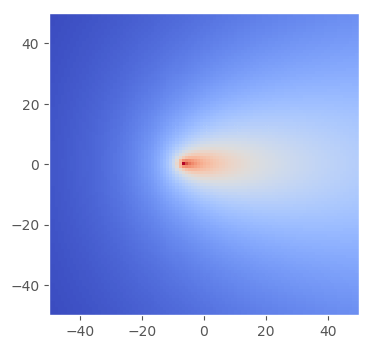

In [9]:
X,Y = np.meshgrid(x,y)

fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=100)#, sharex=True)

map1 = ax.pcolormesh(Y,X,np.log10(phi[:,:,10]+0.01),cmap='coolwarm') #,vmin=0,vmax=0.01)
#map1 = ax.pcolormesh(X,Y,phi[:,:,10],cmap='coolwarm',vmin=0,vmax=0.01)

plt.show()


<IPython.core.display.Javascript object>


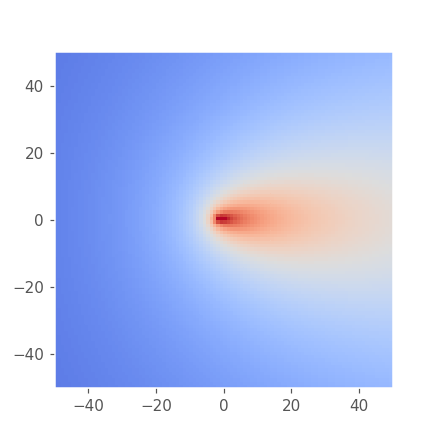

In [10]:
import matplotlib.animation as animation
%matplotlib nbagg 

#fig, ax = plt.subplots(1,1, figsize=(4,4), dpi=100)#, sharex=True)
fig = plt.figure(figsize=(4,4))

ims = []

def up(frame):
    plt.cla()                      # 現在描写されているグラフを消去
    im = plt.pcolormesh(Y,X,np.log10(phi[:,:,frame]+0.01),cmap='coolwarm',
                        vmin=-2,vmax=0.5) 
    plt.show()

ani = animation.FuncAnimation(fig, up, frames=range(0,nt), interval=1)
#plt.show()


In [ ]:
for i in range(nt):
        im = plt.pcolormesh(Y,X,np.log10(phi[:,:,i]+0.01),cmap='coolwarm') 
        ims.append(im)                  # グラフを配列 ims に追加

ani = animation.ArtistAnimation(fig, ims, interval=100, repeat=True)
plt.show()

<IPython.core.display.Javascript object>


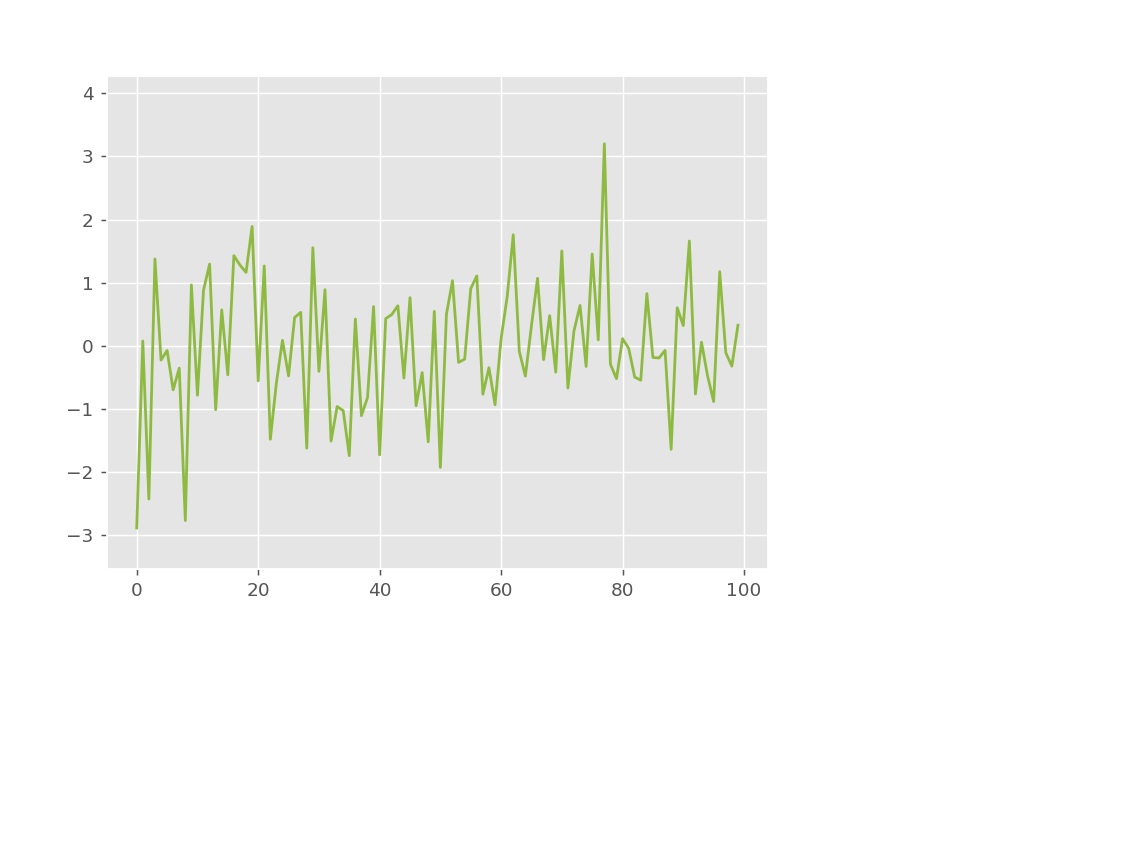

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
%matplotlib nbagg 

fig = plt.figure()

ims = []

for i in range(10):
        rand = np.random.randn(100)     # 100個の乱数を生成
        im = plt.plot(rand)             # 乱数をグラフにする
        ims.append(im)                  # グラフを配列 ims に追加

# 10枚のプロットを 100ms ごとに表示
ani = animation.ArtistAnimation(fig, ims, interval=100)
plt.show()
#ani.save('d:\tmp\g.gif', writer='imagemagick')

<IPython.core.display.Javascript object>


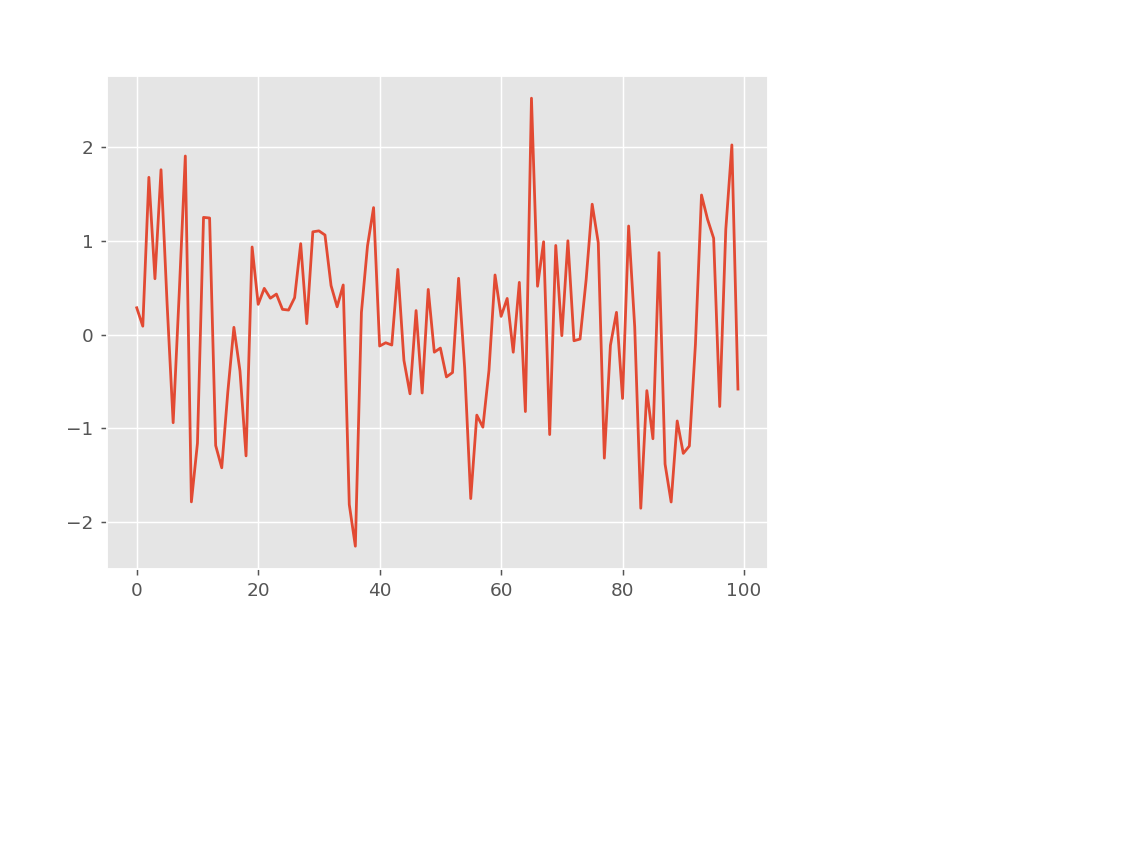

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig = plt.figure()

def plot(data):
    plt.cla()                      # 現在描写されているグラフを消去
    rand = np.random.randn(100)    # 100個の乱数を生成
    im = plt.plot(rand)            # グラフを生成

ani = animation.FuncAnimation(fig, plot, interval=100)
plt.show()

#func.gif

In [25]:
from spectra.src.Util import Class
Class.help(ani)

Attributes
----------------------------------------------------------------------
name                         type               value/len/shape
----------------------------------------------------------------------

save_count                   int                v: 100
repeat                       bool               v: True
frame_seq                    count          
event_source                 TimerBase      

